Mục tiêu.

```
✓ Hiểu Fully Connected Layer

✓ Hiểu Weight Matrix

✓ Hiểu Bias

✓ Hiểu z = Wx + b

✓ Hiểu Output Scores

✓ Hiểu Prediction

✓ Chuẩn bị cho Backpropagation
```

In [9]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.dense import Dense
from src.flatten import Flatten

from src.convolution import Convolution2D
from src.activation import ReLU, Softmax
from src.pooling import MaxPooling2D

from src.utils import (
    load_image,
    show_image
)

In [10]:
print("=" * 60)
print("CNN FROM SCRATCH")
print("09 - DENSE LAYER")
print("=" * 60)

CNN FROM SCRATCH
09 - DENSE LAYER


1. Dense Layer Intuition

```
Dense Layer

Input Vector

↓

Linear Transformation

↓

Output Scores
```

In [11]:
print(
    "Dense Formula: z = Wx + b"
)

Dense Formula: z = Wx + b


- $x$ : Input Vector

- $W$ : Weight Matrix

- $b$ : Bias

- $z$ : Output

2. Manual Example

In [12]:
x = np.array(
[
    1,
    2,
    3
]
)

print(x)

[1 2 3]


In [13]:
W = np.array(
[
    [0.1,0.2,0.3],
    [0.4,0.5,0.6]
]
)

b = np.array(
[
    0.1,
    0.2
]
)

print(W)

[[0.1 0.2 0.3]
 [0.4 0.5 0.6]]


In [14]:
z = W @ x + b

print(z)

[1.5 3.4]


Neuron 1:

0.1×1 + 0.2×2 + 0.3×3 + 0.1 = 1.5

3. Denset Layer Class

In [16]:
dense = Dense(
    input_dim=3,
    output_dim=2
)

dense.summary()


Dense
----------------------------------------
Input Dim  : 3
Output Dim : 2
Parameters : 8
----------------------------------------


In [17]:
print(
    dense.weights.shape
)

(2, 3)


In [18]:
print(
    dense.bias.shape
)

(2,)


4. Forward Pass

In [19]:
x = np.array(
[
    1,
    2,
    3
],
dtype=np.float32)

In [20]:
output = dense.forward(x)

print(output)

[-0.75979416 -0.39975669]


In [21]:
print(
    "Output Shape:",
    output.shape
)

Output Shape: (2,)


5. Multiple Classes

In [22]:
dense = Dense(
    input_dim=8,
    output_dim=4
)

dense.summary()


Dense
----------------------------------------
Input Dim  : 8
Output Dim : 4
Parameters : 36
----------------------------------------


In [23]:
x = np.random.randn(
    8
)

scores = dense.forward(
    x
)

print(scores)

[ 1.77872825 -1.12971823 -1.75271317 -0.26742056]


```
Output Scores

Class 0
Class 1
Class 2
Class 3
```

6. Softmax

In [24]:
softmax = Softmax()

In [25]:
probabilities = softmax.forward(
    scores
)

print(probabilities)

[0.82436508 0.04497771 0.02412315 0.10653405]


In [26]:
print(
    probabilities.sum()
)

0.9999999999999999


Softmax formula:

$$P_i = \frac {e^{z_i}} {\sum_j e^{z_j}}$$

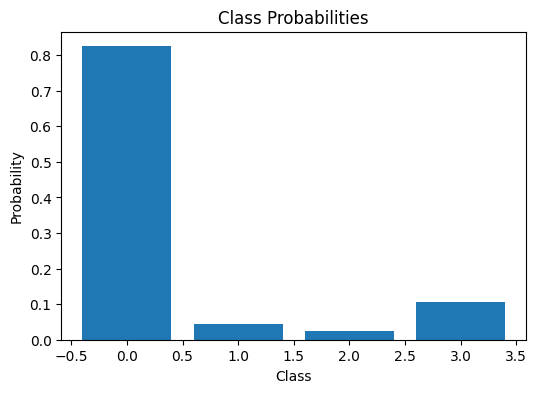

In [27]:
plt.figure(figsize=(6,4))

plt.bar(
    np.arange(
        len(probabilities)
    ),
    probabilities
)

plt.title(
    "Class Probabilities"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Probability"
)

plt.show()

7. Prediction

In [28]:
prediction = np.argmax(
    probabilities
)

print(
    "Predicted Class:",
    prediction
)

Predicted Class: 0


8. Real CNN Example

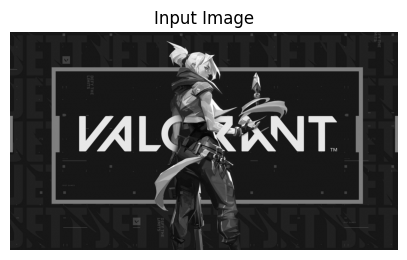

In [30]:
image = load_image(
    "../data/sample2.jpg",
    grayscale=True
)

show_image(
    image,
    "Input Image"
)

In [31]:
conv = Convolution2D(
    in_channels=1,
    out_channels=8,
    kernel_size=3,
    padding=1
)

feature_maps = conv.forward(
    image
)

In [32]:
relu = ReLU()

feature_maps = relu.forward(
    feature_maps
)

In [33]:
pool = MaxPooling2D(
    pool_size=2,
    stride=2
)

feature_maps = pool.forward(
    feature_maps
)

In [34]:
flatten = Flatten()

vector = flatten.forward(
    feature_maps
)

print(
    vector.shape
)

(7372800,)


In [35]:
input_size = len(vector)

print(
    f"{input_size:,}"
)

7,372,800


In [38]:
dense = Dense(
    input_dim=input_size,
    output_dim=10
)

scores = dense.forward(
    vector
)

print(
    scores.shape
)

(10,)


In [37]:
print(scores)

[ 1.77872825 -1.12971823 -1.75271317 -0.26742056]


In [36]:
# Softmax

softmax = Softmax()

probs = softmax.forward(
    scores
)

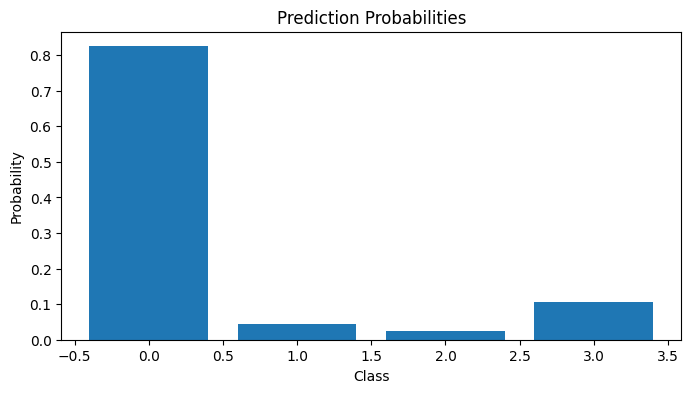

In [42]:
plt.figure(figsize=(8,4))

plt.bar(
    np.arange(len(probs)),
    probs
)

plt.title(
    "Prediction Probabilities"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Probability"
)

plt.show()

9. Parameter Explosion

CNN Problem

Flatten creates huge vectors.

In [40]:
input_size = (
    8 *
    540 *
    960
)

output_size = 10

params = (
    input_size *
    output_size
) + output_size

print(
    f"{params:,}"
)

41,472,010


41 Million+ parameters for one Dense Layer.

10. Why CNN Uses Pooling

In [41]:
sizes = [
    (8,540,960),
    (8,270,480),
    (8,135,240)
]

for shape in sizes:

    total = np.prod(shape)

    print(
        shape,
        "->",
        f"{total:,}"
    )

(8, 540, 960) -> 4,147,200
(8, 270, 480) -> 1,036,800
(8, 135, 240) -> 259,200
